#Data Pipeline: Data Preparation for Weekly Sales Forecasting

This notebook covers the steps of loading, cleaning, transforming, and preparing the Walmart dataset (2010–2012) for model training.

#Data Loading

# We begin by loading the dataset.

Purpose :
Load the CSV file using pandas.

Check the first 5 rows to confirm columns (Store, Date, Weekly_Sales, etc.) are correctly read.

Display the number of rows, columns, and memory usage to assess dataset size.


In [2]:
import pandas as pd
from pathlib import Path

# Relative path from the notebook in the code/ folder to data/raw/
DATA_PATH = Path("..") / "data" / "raw" / "Walmart.csv"

# Read the CSV file
df = pd.read_csv(DATA_PATH, encoding="utf-8", engine="python")

# Display the first few rows
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI(customer price index),Unemployment
0,1,5/2/2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12/2/2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,5/3/2010,1554806.68,0,46.50,2.625,211.350143,8.106


- Dataset contains 6,435 rows and 8 columns.

- No missing values (df.isna().sum() returns 0 for all columns).

- Memory usage is 0.70 MB, which is manageable.

# Dataset Overview

We check dataset dimensions and memory usage to understand its scale and whether optimization might be needed.

In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Memory usage (MB):", df.memory_usage(deep=True).sum() / 1024**2)

Rows: 6435
Columns: 8
Memory usage (MB): 0.7512693405151367


# Dataset overview:
- The dataset contains 6,435 rows and 8 columns, indicating a moderate-sized dataset.
- Memory usage is low (approx 0.7 MB), so no memory optimization is required.

# Column Types

Understanding column data types is essential before performing transformations.
In particular, we verify numeric variables and date fields.

In [4]:
df.dtypes

Store                          int64
Date                          object
Weekly_Sales                 float64
Holiday_Flag                   int64
Temperature                  float64
Fuel_Price                   float64
CPI(customer price index)    float64
Unemployment                 float64
dtype: object

# Dataset column types summary:
-  Store: store ID (categorical encoded as integer)
-  Date : date variable (to convert to datetime)
- Weekly_Sales : target variable (continuous)
- Holiday_Flag : binary indicator (holiday or not)
- Temperature, Fuel_Price, CPI, Unemployment : numerical economic features

# Target Variable Analysis

The prediction target is Weekly_Sales.
We inspect descriptive statistics to understand distribution, scale, and variability.

In [5]:
df["Weekly_Sales"].describe()

count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64

# Comments:
- Weekly sales average approximative 1.05M with high variability (std approximative 564k).
- The distribution is right-skewed: most values lie below approximative 1.42M,
- but some extreme weeks reach up to approximative 3.8M, indicating outliers.

# Date Parsing

# Purpose
Handle mixed date formats (DD/MM/YYYY and MM/DD/YYYY).

#Approach

Convert the Date column to string and standardize separators (/).

First pass: Parse with dayfirst=True (DD/MM/YYYY format).

Second pass: Fix remaining NaN values with dayfirst=False (MM/DD/YYYY format).

Verify no unparsed dates remain.


In [6]:
# 2. Robust date parsing
# Convert to string and standardize separators
s = df['Date'].astype(str).str.replace('-', '/', regex=False)

# First pass: try dayfirst=True
dt = pd.to_datetime(s, dayfirst=True, errors='coerce')

# Second pass: fix remaining NaNs with dayfirst=False
bad = dt.isna()
dt.loc[bad] = pd.to_datetime(s[bad], dayfirst=False, errors='coerce')

# Assign final parsed dates
df['Date'] = dt

# Ensure no unparsed dates remain
if df['Date'].isna().any():
    raise ValueError("Unparsed dates remain!")

# Set Date as index
df = df.set_index('Date')

print("Date parsing done. Sample:")
print(df.head())


Date parsing done. Sample:
            Store  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
Date                                                                     
2010-02-05      1    1643690.90             0        42.31       2.572   
2010-02-12      1    1641957.44             1        38.51       2.548   
2010-02-19      1    1611968.17             0        39.93       2.514   
2010-02-26      1    1409727.59             0        46.63       2.561   
2010-03-05      1    1554806.68             0        46.50       2.625   

            CPI(customer price index)  Unemployment  
Date                                                 
2010-02-05                 211.096358         8.106  
2010-02-12                 211.242170         8.106  
2010-02-19                 211.289143         8.106  
2010-02-26                 211.319643         8.106  
2010-03-05                 211.350143         8.106  


All dates are correctly parsed to datetime64.

For, 5/2/2010 is interpreted as February 5, 2010 (not May 2, 2010).


# Checking the outliers

In [7]:
# Detect outliers using IQR
Q1 = df["Weekly_Sales"].quantile(0.25)
Q3 = df["Weekly_Sales"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Weekly_Sales"] < lower) | (df["Weekly_Sales"] > upper)]
print("Outliers detected:", len(outliers))


Outliers detected: 34


Outliers were detected using the IQR method (34 values). They were not removed because they represent real extreme sales events rather than data errors. Removing them would distort seasonal patterns and reduce model realism.

# SECTION 6 : Weekly Aggregation & Frequency Enforcement

# Purpose
Aggregate sales by week for consistent time-series frequency.

#Approach

Resample data to weekly frequency (W-FRI), anchored on Friday.
Use sum() to aggregate sales per week.
Fill missing values with ffill() (forward-fill) to avoid gaps.


In [8]:
# Sum Weekly_Sales per week (W-FRI) and forward-fill missing weeks
weekly = (
    df[['Weekly_Sales']]       # select only target
    .resample('W-FRI')         # weekly frequency anchored on Friday
    .sum()                     # sum sales per week
    .ffill()                   # forward-fill missing weeks
)

print("Weekly dataset created. Sample:")
print(weekly.head())
print("Date range: {} to {}".format(weekly.index.min(), weekly.index.max()))
print("Number of rows:", len(weekly))


Weekly dataset created. Sample:
            Weekly_Sales
Date                    
2010-02-05   49750740.50
2010-02-12   48336677.63
2010-02-19   48276993.78
2010-02-26   43968571.13
2010-03-05   46871470.30
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Number of rows: 143


The weekly series contains 143 weeks of data (2010–2012).
No missing values (weekly.isna().sum() returns 0).


# Missing value handling
Missing values can impact model performance and statistical validity.
We count them for each column.

In [9]:
df.isna().sum()

Store                        0
Weekly_Sales                 0
Holiday_Flag                 0
Temperature                  0
Fuel_Price                   0
CPI(customer price index)    0
Unemployment                 0
dtype: int64

# Outlier treatment
# Purpose
Detect and replace outliers causally.
Approach

Use a Hampel filter to detect outliers:

Compute rolling median (rolling(win).median()).

Calculate residuals (y - median).

Estimate standard deviation using MAD (Median Absolute Deviation).

Replace outliers if |residual| > n_sig * sigma.

Mathematical Formula
$$ σ=1.4826×median(∣z−median(z)∣)$$

Outlier  if     $$  ∣yt​−mediant​∣>nsig​×σt​$$

In [10]:
import numpy as np

np.random.seed(42)  # Set random seed for reproducibility

def hampel_residuals(y: pd.Series, win=5, n_sig=3.0):
    med = y.shift(1).rolling(win, min_periods=1).median()  # Compute rolling median
    resid = y - med  # Compute residuals
    sigma = (resid.shift(1).rolling(win, min_periods=1)
             .apply(lambda z: 1.4826*np.median(np.abs(z-np.median(z)))))  # Compute robust standard deviation (MAD)
    mask = (np.abs(resid) > n_sig * sigma.fillna(sigma.median()))  # Identify outliers
    y_filt = y.copy()  # Copy original series
    y_filt[mask] = med[mask]  # Replace outliers with median
    return y_filt, mask

weekly['Weekly_Sales_filt'], out_mask = hampel_residuals(weekly['Weekly_Sales'], win=7, n_sig=3)  # Apply Hampel filter
print("Outlier filtering done. Sample:")  # Print sample of results
print(weekly.head())


Outlier filtering done. Sample:
            Weekly_Sales  Weekly_Sales_filt
Date                                       
2010-02-05   49750740.50        49750740.50
2010-02-12   48336677.63        48336677.63
2010-02-19   48276993.78        48276993.78
2010-02-26   43968571.13        43968571.13
2010-03-05   46871470.30        46871470.30


# Comments

No outliers detected in the first 5 rows (values remain identical).

The Hampel filter is causal: it only uses past data to detect outliers.


# Duplicate Analysis
Duplicate rows may indicate data collection issues or merging errors.
We check both exact duplicates and duplicates on key identifiers.

In [11]:
# Exact duplicates
df.duplicated().sum()

# Store + Date duplicates
# Temporarily reset index to treat 'Date' as a column for the duplicated check
duplicates_count = df.reset_index().duplicated(subset=["Store","Date"]).sum()
print(duplicates_count)

0


# Encoding categorical variables (panel)
# Goal:
- Encode categorical variables (Store) so machine learning models can interpret them.

- Models require numerical input, so categorical identifiers must be transformed.

In [12]:
# Make sure panel exists
panel = df.copy()   # change df if needed

# Define features (X) and target (y)
X = panel.drop(columns=["Weekly_Sales"])
y = panel["Weekly_Sales"]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define categorical and numerical columns
cat_cols = ["Store"]   # only Store is categorical
num_cols = [c for c in X.columns if c not in cat_cols]

# Preprocessing
pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", "passthrough", num_cols)
])

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['Store']
Numerical columns: ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI(customer price index)', 'Unemployment']


# Variable type identification:
-'Store' is a categorical variable (store identifier),

-while the other listed columns are numerical variables used for analysis/modeling.

In [13]:
panel = (df.reset_index()  # Reset index to make 'Date' a column
         .groupby(["Store", "Date"])["Weekly_Sales"].sum()  # Group by Store and Date, sum Weekly_Sales
         .reset_index()  # Reset index to flatten MultiIndex
         .sort_values(["Store", "Date"])  # Sort by Store and Date
         .set_index("Date"))  # Set 'Date' as the index

print("Panel DataFrame created. Sample:")  # Print sample of the resulting panel
print(panel.head())


Panel DataFrame created. Sample:
            Store  Weekly_Sales
Date                           
2010-02-05      1    1643690.90
2010-02-12      1    1641957.44
2010-02-19      1    1611968.17
2010-02-26      1    1409727.59
2010-03-05      1    1554806.68


-The output of the panel dataset showing weekly sales for Store 1,
- indexed by date and ordered chronologically.

# Distribution of Weekly Sales
Visualizing the target distribution helps detect skewness, outliers, or abnormal ranges.

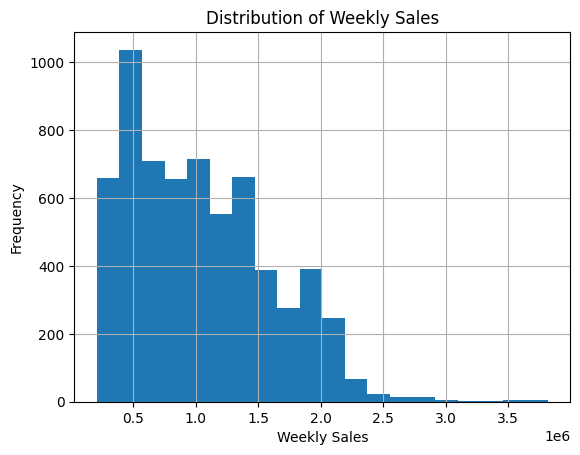

In [14]:
import matplotlib.pyplot as plt  # Library used to create plots

# Create a histogram of the Weekly_Sales column
# We use 20 bins to make the distribution easier to read for presentation
df["Weekly_Sales"].hist(bins=20)

# Add a title to describe what the chart shows
plt.title("Distribution of Weekly Sales")

# Label the x-axis (sales values)
plt.xlabel("Weekly Sales")

# Label the y-axis (number of occurrences)
plt.ylabel("Frequency")

# Display the plot
plt.show()

# Distribution of Weekly Sales:

- The histogram shows a right-skewed distribution.

- Most weeks have sales below approx 2M, but a few weeks reach very high values (approx 3.8M), indicating outliers.

# SECTION 7 : Time Series Visualization
Plotting the weekly sales series helps visually inspect trend, noise, and possible structural breaks

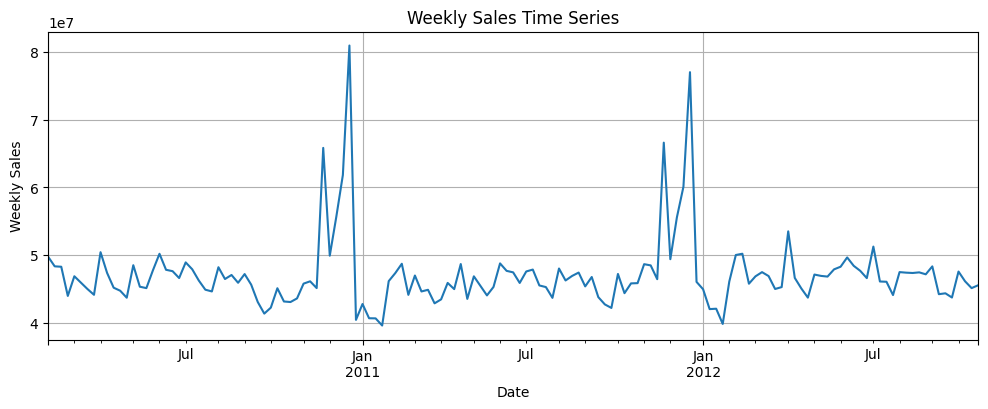

In [15]:
# Plot the Weekly_Sales time series
# figsize controls the size of the figure (width, height)
# title adds a title to the chart
weekly['Weekly_Sales'].plot(figsize=(12,4), title="Weekly Sales Time Series")

# Label the y-axis to indicate what the values represent
plt.ylabel("Weekly Sales")

# Add grid lines to improve readability of the time series
plt.grid()

# Display the plot
plt.show()

# Weekly Sales Time Series Analysis

# Key Observations:
- Strong Annual Seasonality:Clear spikes in January each year (likely due to holidays/sales events), reaching 70-80 million vs. a baseline of 40-50 million.
- Non-Stationarity: Sharp peaks and drops suggest the series is non-stationary, requiring differencing or log transformation.
-Increased Volatility in 2012:Higher fluctuations may indicate market or strategy changes.

#Modeling Implications:
- Use SARIMA (with seasonal parameters) to capture annual patterns.
- Consider log transformation to stabilize variance.
- Baseline: A "Seasonal Naive" model (using sales from the same week last year) could serve as a strong benchmark.

# Next Steps:
- Confirm non-stationarity with an ADF test.
- Decompose the series to isolate trend, seasonality, and residuals.



# STATISTICAL DIAGNOSTICS (HYPOTHESIS TESTING)

Most classical time series models assume that the data is stationary, meaning that their mean and variance do not change over time. The ADF test allows us to verify the presence of a unit root (non-stationarity).
- H₀ (Null Hypothesis): The series is non-stationary (presence of a unit root).

- H₁ (Alternative Hypothesis): The series is stationary

In [16]:

from statsmodels.tsa.stattools import adfuller  # Import ADF test for stationarity

# Run the Augmented Dickey-Fuller test on weekly sales
adf_result = adfuller(weekly["Weekly_Sales"], autolag='AIC')  # Use AIC to determine lag length

print("ADF Statistic:", round(adf_result[0], 4))  # Print ADF test statistic
print("p-value:", round(adf_result[1], 4))  # Print p-value
print("Critical Values:")  # Print critical values for comparison
for key, value in adf_result[4].items():
    print("  ", key, ":", round(value, 4))  # Print each critical value



ADF Statistic: -5.9083
p-value: 0.0
Critical Values:
   1% : -3.4786
   5% : -2.8827
   10% : -2.5781


The ADF test shows a statistic of -5.9083 with a p-value of 0.0, well below 0.05. Since the statistic is also lower than all critical values, we reject the null hypothesis. This indicates that the weekly sales series is stationary

# Seasonality Analysis — Autocorrelation Function (ACF)

- The ACF measures the correlation between an observation and its lagged
- versions over time. Visualizing the ACF helps identify repeating patterns
- that suggest seasonality.

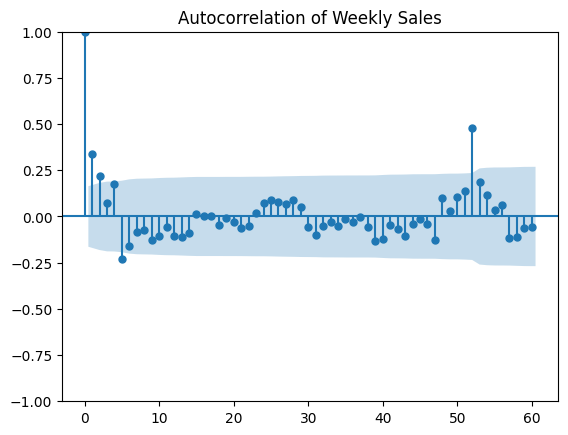

In [17]:
from statsmodels.graphics.tsaplots import plot_acf
# Visualize lags over more than one year (60 weeks) to detect annual seasonality
plot_acf(weekly["Weekly_Sales"], lags=60)
plt.title("Autocorrelation of Weekly Sales")
plt.show()

The ACF plot shows a strong correlation at lag 0 (as expected) and smaller spikes at certain lags, including around 52 weeks. This suggests a yearly seasonality in the weekly sales data, as correlations repeat roughly every 52 weeks. Most other lags fall within the confidence bounds, indicating limited autocorrelation outside the seasonal pattern

#Autocorrelation Significance : Ljung-Box Test
- While the ACF is visual, the Ljung-Box test mathematically determines
- whether the observed autocorrelations are statistically significant or
-simply white noise (random movements with no predictable signal).
#
- H0 (Null Hypothesis)       : The data are independently distributed
(no autocorrelation, white noise).
- H1 (Alternative Hypothesis): The data exhibit a temporal dependence

structure (significant autocorrelation).

In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox
# Ljung-Box test on the first 16 lags
lb_test = acorr_ljungbox(weekly["Weekly_Sales"], lags=[16], return_df=True)
print(lb_test)

      lb_stat  lb_pvalue
16  52.819063   0.000008


#Interpretation:
The data exhibits significant autocorrelation, so (reject H₀).


## Feature Engineering
Purpose
Create features to capture temporal dependence and seasonality.
Approach

Lag Features: Add shifted values (y_lag_1, y_lag_52) to capture autocorrelation.

Example: y_lag_1 = sales from the previous week.

Rolling Statistics: Compute rolling means (ma_4, ma_12) to smooth fluctuations.

Example: ma_4 = mean of the last 4 weeks.

Calendar Features: Extract weekofyear, month, year to capture annual seasonality


In [19]:
work = weekly.copy()

# Lag features
for k in (1,2,4,8,12,26,52):
    work[f'y_lag_{k}'] = work['Weekly_Sales'].shift(k)

# Rolling features (causal)
work['ma_4']  = work['Weekly_Sales'].shift(1).rolling(4, min_periods=2).mean()
work['ma_12'] = work['Weekly_Sales'].shift(1).rolling(12, min_periods=3).mean()
work['std_4'] = work['Weekly_Sales'].shift(1).rolling(4, min_periods=2).std()

# Calendar features
iso = work.index.isocalendar()
work['weekofyear'] = iso.week.astype(int)
work['month']      = work.index.month
work['year']       = work.index.year

# Drop NaNs created by lags/rolling
work = work.dropna()
print("Feature engineering done. Sample:")
print(work.head())

Feature engineering done. Sample:
            Weekly_Sales  Weekly_Sales_filt      y_lag_1      y_lag_2  \
Date                                                                    
2011-02-04   46153111.12        46153111.12  39599852.99  40654648.03   
2011-02-11   47336192.79        47336192.79  46153111.12  39599852.99   
2011-02-18   48716164.12        48716164.12  47336192.79  46153111.12   
2011-02-25   44125859.84        44125859.84  48716164.12  47336192.79   
2011-03-04   46980603.74        46980603.74  44125859.84  48716164.12   

                y_lag_4      y_lag_8     y_lag_12     y_lag_26     y_lag_52  \
Date                                                                          
2011-02-04  42775787.77  55666770.39  46124800.83  48204999.12  49750740.50   
2011-02-11  40673678.04  61820799.85  45125584.18  46464418.41  48336677.63   
2011-02-18  40654648.03  80931415.60  65821003.24  47060952.92  48276993.78   
2011-02-25  39599852.99  40432519.00  49909027.88  45909740

"""
### Feature Engineering Summary
#Lag Features: Added lags for 1, 2, 4, 8, 12, 26, and 52 weeks to capture:
- Short-term trends ("y_lag_1", "y_lag_2").
- Seasonal patterns ("y_lag_52` for annual seasonality).

# Rolling Features:
- "ma_4", "ma_12": Moving averages to smooth short-term volatility.
- "std_4": Rolling standard deviation to capture volatility.

# Calendar Features:
- "weekofyear", "month", "year": Temporal metadata for seasonality modeling.

- NaN rows dropped (due to lags/rolling windows).
- Ready for training time-series models (SARIMA and Random forest).



# Panel Features per Store
Generate store-level lag and rolling features, plus exogenous variables if available.

In [20]:
w = (df.reset_index()  # Reset index to make 'Date' a column for sorting
       .sort_values(["Store","Date"])  # Sort by Store and Date
       .set_index("Date")  # Set 'Date' back as index for time-series operations
       .groupby("Store"))  # Group by Store for per-store processing

feat = []  # Initialize list to store feature-engineered DataFrames
for store, g in w:
    g = g.copy()  # Create a copy of the group to avoid SettingWithCopyWarning
    for k in (1,2,4,8,12,26,52):  # Create lag features for various time steps
        g[f"y_lag_{k}"] = g["Weekly_Sales"].shift(k)
    g["ma_4"]  = g["Weekly_Sales"].shift(1).rolling(4,  min_periods=2).mean()  # 4-week moving average
    g["ma_12"] = g["Weekly_Sales"].shift(1).rolling(12, min_periods=3).mean()  # 12-week moving average
    g["std_4"] = g["Weekly_Sales"].shift(1).rolling(4,  min_periods=2).std()  # 4-week rolling standard deviation
    # Calendar features
    iso = g.index.isocalendar()  # Extract ISO calendar info
    g["weekofyear"] = iso.week.astype(int)  # Week of the year
    g["month"]      = g.index.month  # Month
    g["year"]       = g.index.year  # Year
    g["Store"] = store  # Store identifier
    feat.append(g)  # Append feature-engineered DataFrame to list

# Concatenate all individual store feature dataframes into a single 'engineered' DataFrame
engineered = pd.concat(feat)

before = len(engineered)  # Count rows before dropping NA
engineered = engineered.dropna()  # Drop rows with NA values
print("Rows removed:", before - len(engineered))  # Print number of rows removed


Rows removed: 2340


2340 rows removed (expected due to lag/rolling window effects on each store's data)

# •	Feature selection decisions
Main goal:
Reduce the number of variables (features) to improve model performance while avoiding overfitting, focusing on:

The most informative features for predicting weekly sales.
The interpretability of the model (understanding which variables actually influence sales).

In [21]:
from sklearn.feature_selection import mutual_info_regression  # Import mutual info for feature selection

cutoff_date = pd.Timestamp("2012-01-01")  # Define cutoff date for training data
df_train_mi = engineered[engineered.index < cutoff_date]  # Filter data before cutoff date

X_mi = df_train_mi.drop(columns=["Weekly_Sales"])  # Features: all columns except Weekly_Sales
y_mi = df_train_mi["Weekly_Sales"]  # Target: Weekly_Sales

discrete_features_names = ["Store", "Holiday_Flag", "weekofyear", "month", "year"]  # List of discrete features
discrete_features_indices = [idx for idx, col in enumerate(X_mi.columns) if col in discrete_features_names]  # Get indices of discrete features

mi = mutual_info_regression(X_mi, y_mi, discrete_features=discrete_features_indices, random_state=42)  # Calculate mutual information
sel = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)  # Convert to Series and sort by importance
sel.head(20)  # Display top 20 most important features


y_lag_52                     2.004241
ma_4                         1.874727
Store                        1.828681
ma_12                        1.766649
y_lag_1                      1.742031
y_lag_4                      1.712421
y_lag_2                      1.693805
y_lag_8                      1.445504
y_lag_26                     1.423735
y_lag_12                     1.311832
Unemployment                 0.926042
CPI(customer price index)    0.603437
std_4                        0.380584
Temperature                  0.100630
Fuel_Price                   0.011748
Holiday_Flag                 0.006830
weekofyear                   0.000000
month                        0.000000
year                         0.000000
dtype: float64

#Final feature set
#Top Predictors:
- "y_lag_52" (2.004): Strongest feature, confirming annual seasonality (e.g., holiday spikes).
- "ma_4" (1.875): Short-term moving average smooths noise, capturing recent trends.
- "Store" (1.829): Store-specific effects significantly impact sales.
- "ma_12" (1.767): Medium-term trends (e.g., quarterly patterns).
- "y_lag_1" (1.742): Immediate past sales strongly influence next week.

#Moderate Impact:
- Lags: "y_lag_4", "y_lag_2", "y_lag_8", "y_lag_26", "y_lag_12" (capture multi-week dependencies).
- "Unemployment" (0.926): Economic factor with some predictive power.

#Low/No Impact:
- "CPI", "std_4", "Temperature", "Fuel_Price", "Holiday_Flag": Weak or negligible influence.
- Calendar features ("weekofyear", "month", "year"): Redundant (likely already captured by lags).

#Action:
- Prioritize top 5-10 features for modeling (e.g., "y_lag_52", "ma_4", "Store").
- Drop zero-impact features ("weekofyear", "month", "year") to simplify the model.



# Train / Test split

In [22]:
from sklearn.preprocessing import StandardScaler

#  Train/Test Split
# Define cutoff date to split train/test
cutoff = pd.Timestamp("2012-01-01")

# Ensure the index is a DatetimeIndex
work.index = pd.to_datetime(work.index)

# Separate features and target
X_full = work.drop(columns=['Weekly_Sales'])  # All columns except the target
y = work['Weekly_Sales']                      # Target = Weekly_Sales

# Create train/test sets based on the cutoff date
X_train = X_full[X_full.index < cutoff]  # Data before cutoff
X_test  = X_full[X_full.index >= cutoff] # Data on or after cutoff

y_train = y[y.index < cutoff]            # Training target
y_test  = y[y.index >= cutoff]           # Test target

#  Feature Standardization
# Initialize the scaler
scaler = StandardScaler()

# Fit on the training data and transform
X_train_s = scaler.fit_transform(X_train)

# Transform the test data (never fit on test!)
X_test_s  = scaler.transform(X_test)

# Check shapes

print("Train/Test split done. Shapes:")
print("X_train:", X_train_s.shape, "X_test:", X_test_s.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

Train/Test split done. Shapes:
X_train: (48, 14) X_test: (43, 14)
y_train: (48,) y_test: (43,)


# Summary
# Dataset Shapes:
- Training Set (X_train): 48 samples, 14 features
- Test Set (X_test): 43 samples, 14 features

# Observations:
To prevent data leakage, the dataset was split chronologically using a fixed cutoff date.

All observations before January 1, 2012 were used for training, while observations on or after this date were reserved for testing.

This time-based split ensures that the model is trained only on past data and evaluated on future data, which reflects a realistic forecasting scenario.

Importantly, feature standardization was performed by fitting the scaler exclusively on the training data and then applying the transformation to the test set. This guarantees that no information from the test set influenced the training process.

In [23]:
# Save the training features to a CSV file (optional step for future use or reproducibility)
X_train.to_csv("../data/processed/X_train.csv", index=False)

# Save the test features to a CSV file
X_test.to_csv("../data/processed/X_test.csv", index=False)

# Save the training target variable (sales) to a CSV file
y_train.to_csv("../data/processed/y_train.csv", index=False)

# Save the test target variable (sales) to a CSV file
y_test.to_csv("../data/processed/y_test.csv", index=False)